Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Loading both the datasets

In [2]:
trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

View the first 5 rows

In [3]:
print("Historical Data")
display(trades.head())

print("\nFear & Greed Data")
display(fear.head())

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Data


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Checking the dataset information

In [4]:
print("Historical Data Info")
trades.info()

print("\nFear & Greed Info")
fear.info()

Historical Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtyp

In [6]:
# Convert Timestamp IST (automatically detect mixed formats)
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='mixed',
    dayfirst=True
)

# Convert Fear & Greed date
fear['date'] = pd.to_datetime(fear['date'])

# Create Date column
trades['Date'] = trades['Timestamp IST'].dt.date
fear['Date'] = fear['date'].dt.date

Merge the datasets

In [9]:
merged_df = pd.merge(
    trades,
    fear[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

print("Merged Dataset Shape:", merged_df.shape)
merged_df.head()

Merged Dataset Shape: (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [10]:
merged_df[['Date', 'Coin', 'Closed PnL', 'classification', 'value']].head(10)

,Date,Coin,Closed PnL,classification,value
0,2024-12-02,@107,0.0,Extreme Greed,80.0
1,2024-12-02,@107,0.0,Extreme Greed,80.0
2,2024-12-02,@107,0.0,Extreme Greed,80.0
3,2024-12-02,@107,0.0,Extreme Greed,80.0
4,2024-12-02,@107,0.0,Extreme Greed,80.0
5,2024-12-02,@107,0.0,Extreme Greed,80.0
6,2024-12-02,@107,0.0,Extreme Greed,80.0
7,2024-12-02,@107,0.0,Extreme Greed,80.0
8,2024-12-02,@107,0.0,Extreme Greed,80.0
9,2024-12-02,@107,0.0,Extreme Greed,80.0


Check for Mising Values

In [11]:
merged_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [12]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,51.649656
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,21.012784


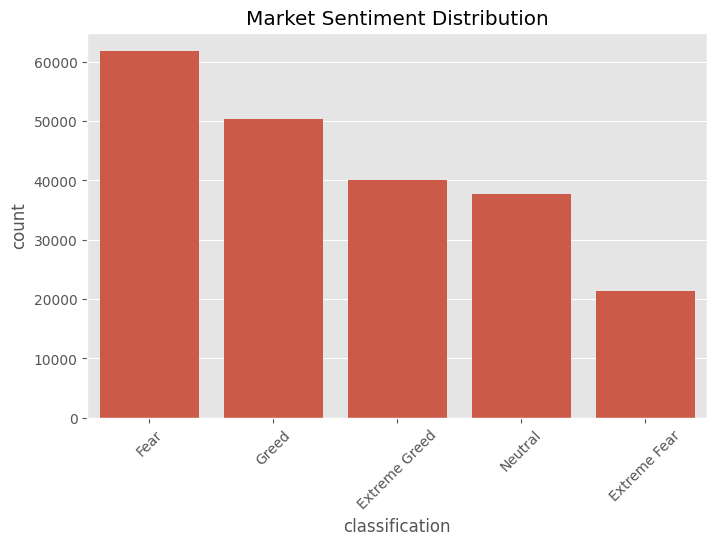

In [13]:
#Market Sentiment Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Market Sentiment Distribution")
plt.show()

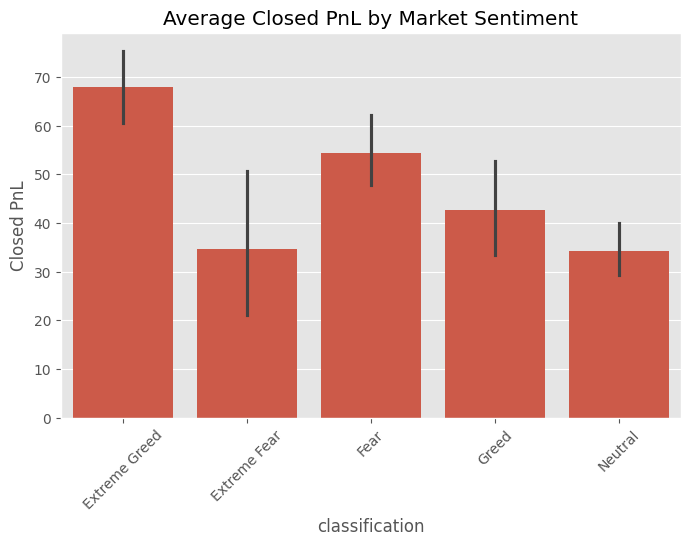

In [14]:
#Profit by Market Sentiment
plt.figure(figsize=(8,5))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    estimator='mean'
)

plt.xticks(rotation=45)
plt.title("Average Closed PnL by Market Sentiment")
plt.show()

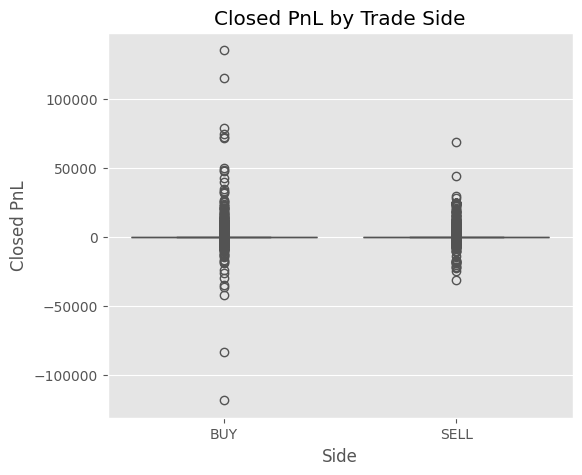

In [15]:
#Buy vs Sell Performance
plt.figure(figsize=(6,5))

sns.boxplot(
    data=merged_df,
    x='Side',
    y='Closed PnL'
)

plt.title("Closed PnL by Trade Side")
plt.show()

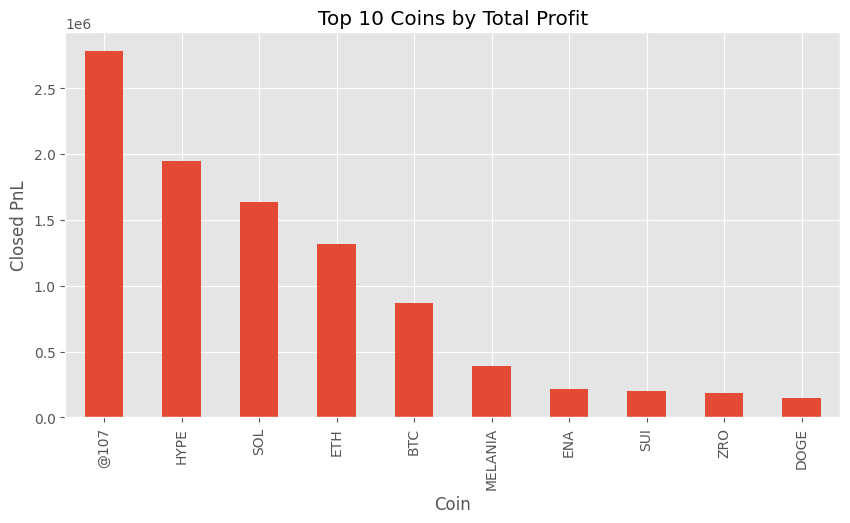

In [16]:
#Top 10 Coins by Profit
top_coin = (
    merged_df.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_coin.plot(kind='bar')

plt.title("Top 10 Coins by Total Profit")
plt.ylabel("Closed PnL")

plt.show()

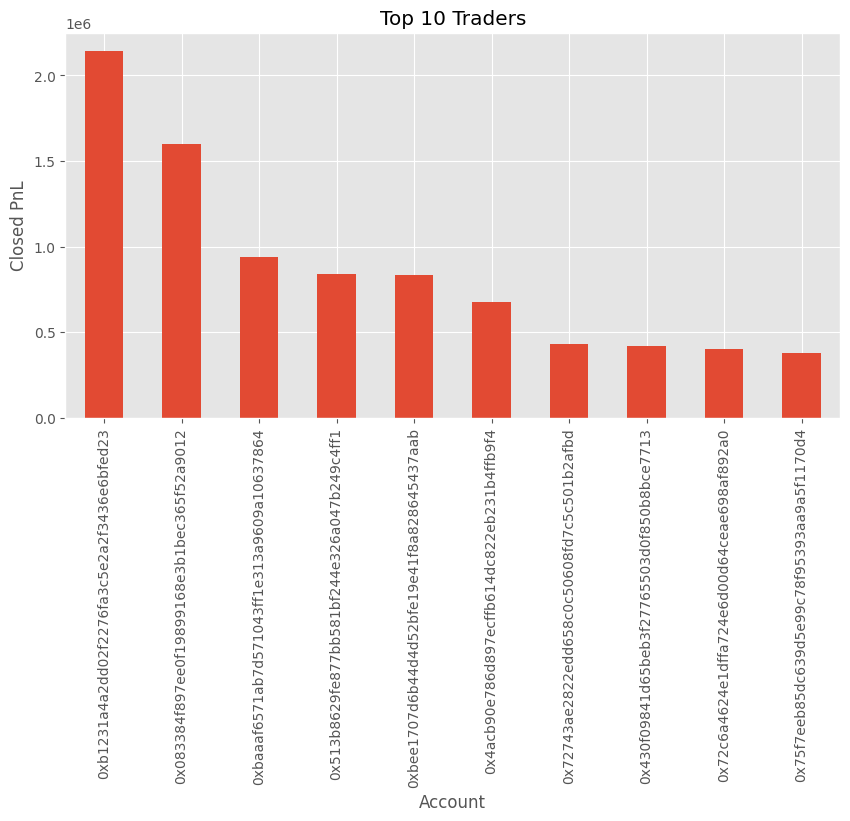

In [17]:
#Top 10 Traders
top_traders = (
    merged_df.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_traders.plot(kind='bar')

plt.title("Top 10 Traders")
plt.ylabel("Closed PnL")

plt.show()

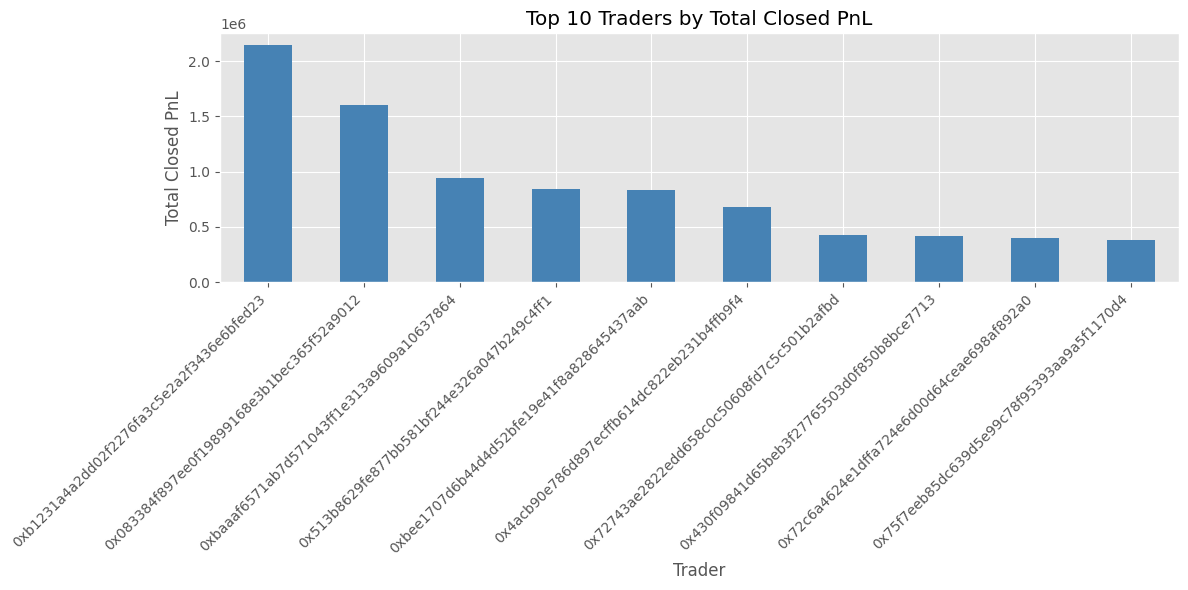

In [19]:
top_traders = (
    merged_df.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_traders.plot(kind='bar', color='steelblue')

plt.title("Top 10 Traders by Total Closed PnL")
plt.xlabel("Trader")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Profit by Market Sentiment

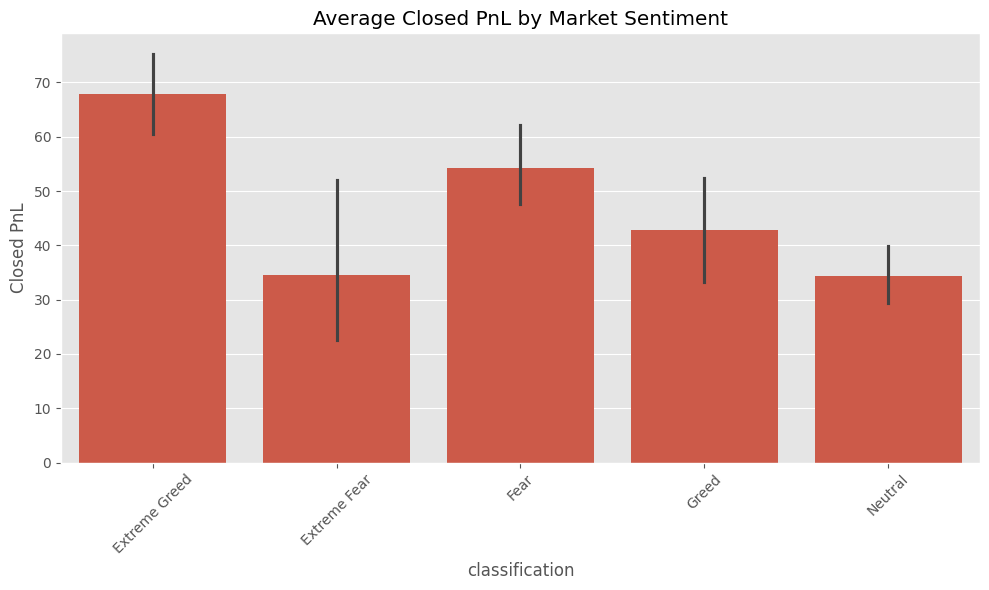

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=merged_df,
    x='classification',
    y='Closed PnL',
    estimator='mean'
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Distribution of Market Sentiment

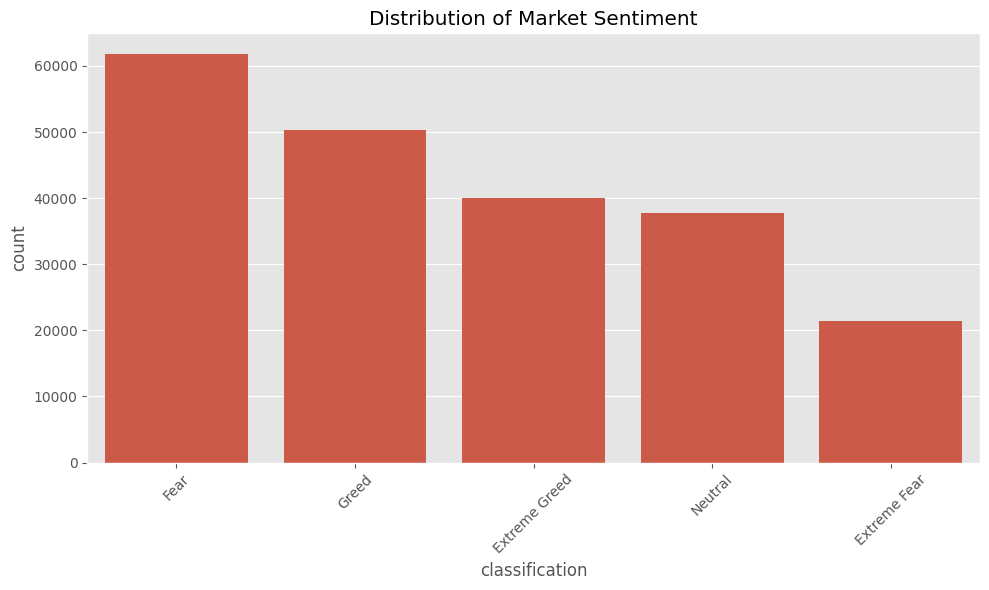

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Buy vs Sell Performance

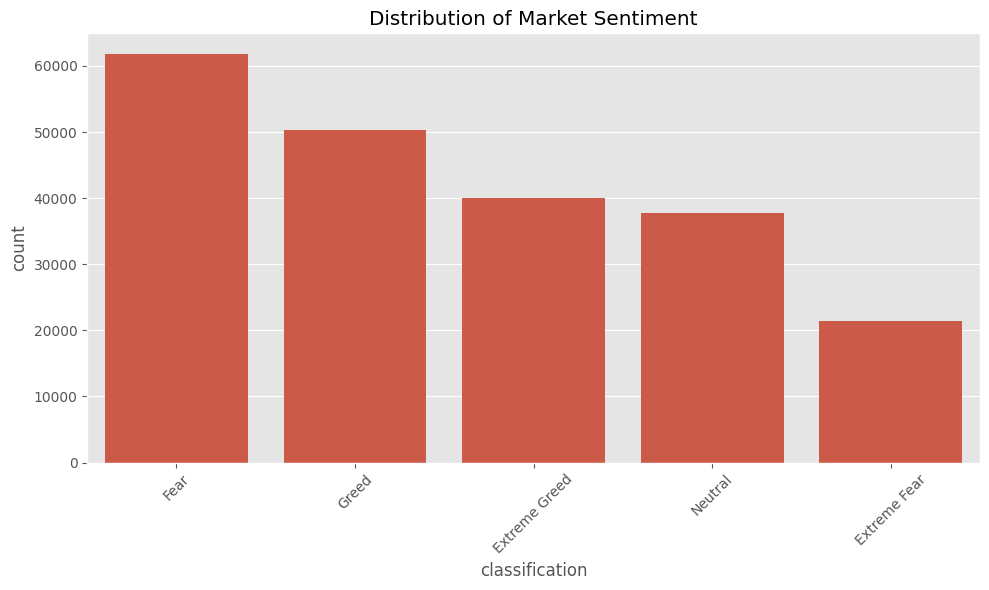

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Coins by Profit

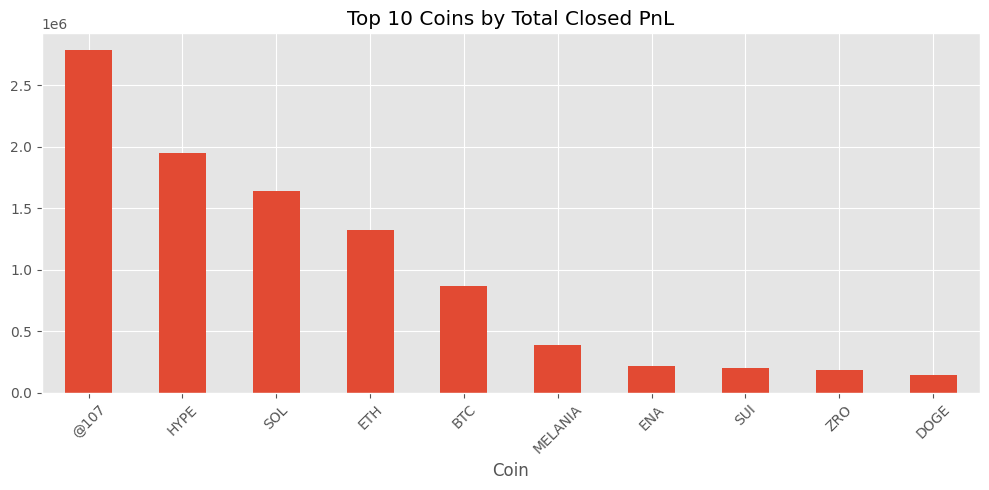

In [25]:
top_coin = (
    merged_df.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_coin.plot(kind='bar')

plt.title("Top 10 Coins by Total Closed PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Market Sentiment Distribution

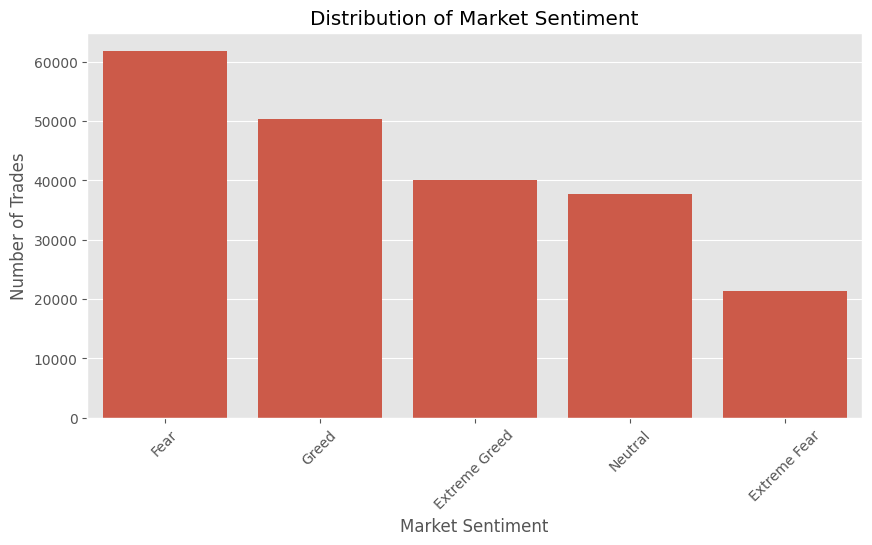

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged_df,
    x='classification',
    order=merged_df['classification'].value_counts().index
)

plt.title("Distribution of Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

Average Profit by Market Sentiment

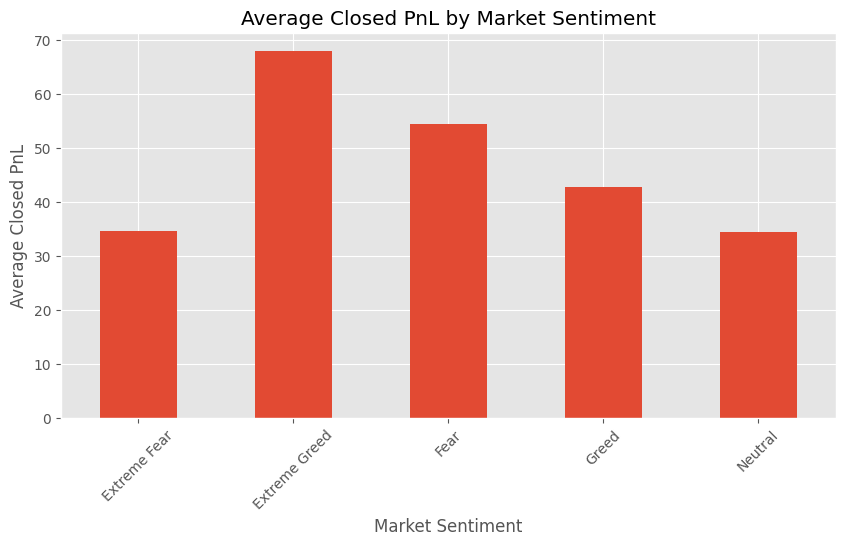

In [27]:
plt.figure(figsize=(10,5))

merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.show()

Buy vs Sell Performance

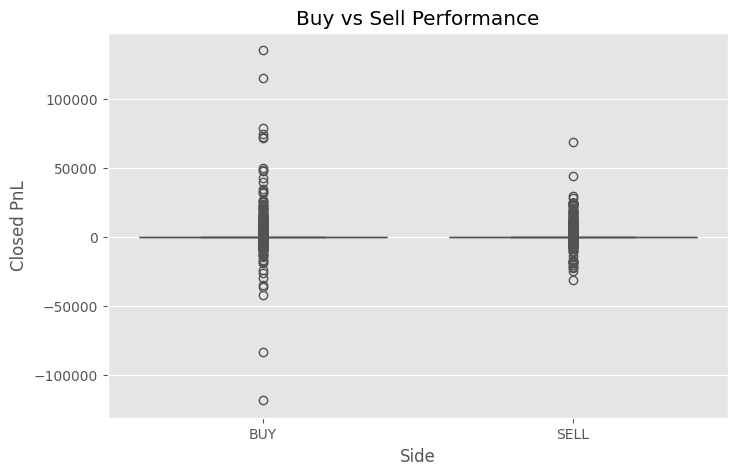

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x='Side',
    y='Closed PnL'
)

plt.title("Buy vs Sell Performance")

plt.show()

Correlation Headmap

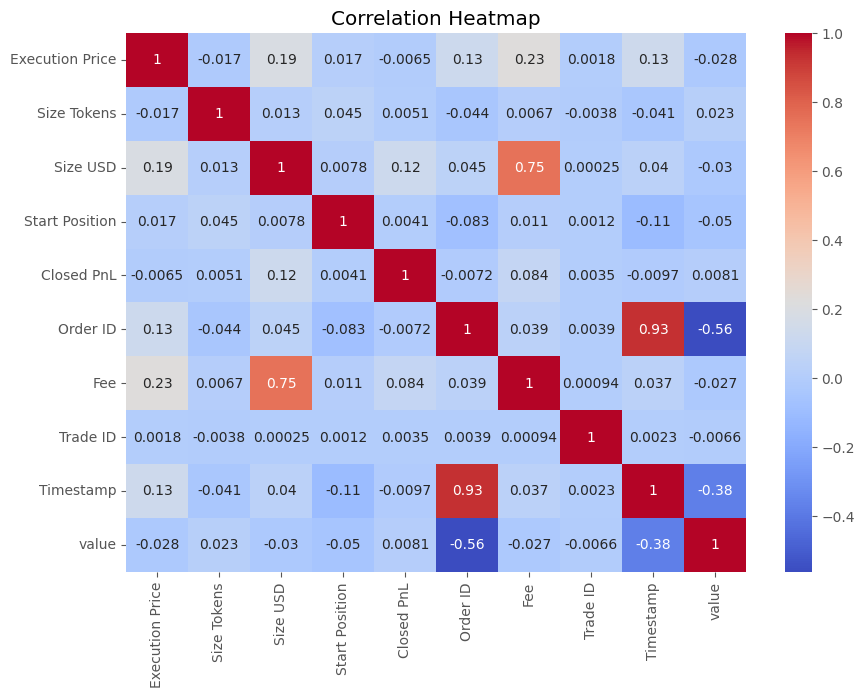

In [29]:
plt.figure(figsize=(10,7))

numeric = merged_df.select_dtypes(include='number')

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()